In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
day = pd.read_csv("day.csv")
hour = pd.read_csv("hour.csv")


In [10]:
cols_to_drop = ['instant', 'dteday', 'yr', 'casual', 'registered']

day = day.drop(cols_to_drop, axis=1)
hour = hour.drop(cols_to_drop, axis=1)


In [11]:
print("Day shape:", day.shape)
print("Hour shape:", hour.shape)


Day shape: (731, 11)
Hour shape: (17379, 12)


In [12]:
print("Day columns:\n", day.columns)
print("\nHour columns:\n", hour.columns)


Day columns:
 Index(['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit',
       'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

Hour columns:
 Index(['season', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')


In [13]:
day.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      731 non-null    int64  
 1   mnth        731 non-null    int64  
 2   holiday     731 non-null    int64  
 3   weekday     731 non-null    int64  
 4   workingday  731 non-null    int64  
 5   weathersit  731 non-null    int64  
 6   temp        731 non-null    float64
 7   atemp       731 non-null    float64
 8   hum         731 non-null    float64
 9   windspeed   731 non-null    float64
 10  cnt         731 non-null    int64  
dtypes: float64(4), int64(7)
memory usage: 62.9 KB


In [14]:
hour.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17379 non-null  int64  
 1   mnth        17379 non-null  int64  
 2   hr          17379 non-null  int64  
 3   holiday     17379 non-null  int64  
 4   weekday     17379 non-null  int64  
 5   workingday  17379 non-null  int64  
 6   weathersit  17379 non-null  int64  
 7   temp        17379 non-null  float64
 8   atemp       17379 non-null  float64
 9   hum         17379 non-null  float64
 10  windspeed   17379 non-null  float64
 11  cnt         17379 non-null  int64  
dtypes: float64(4), int64(8)
memory usage: 1.6 MB


In [15]:
print("Missing values in DAY dataset:\n", day.isnull().sum())


Missing values in DAY dataset:
 season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


In [16]:
print("\nMissing values in HOUR dataset:\n", hour.isnull().sum())



Missing values in HOUR dataset:
 season        0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


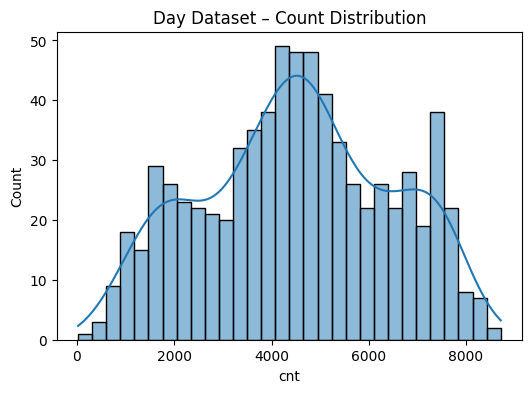

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(day['cnt'], bins=30, kde=True)
plt.title("Day Dataset – Count Distribution")
plt.show()


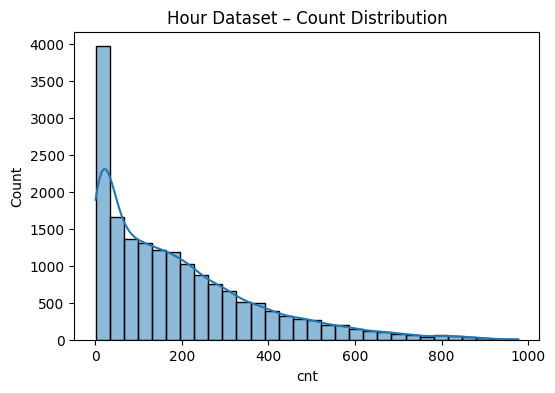

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(hour['cnt'], bins=30, kde=True)
plt.title("Hour Dataset – Count Distribution")
plt.show()


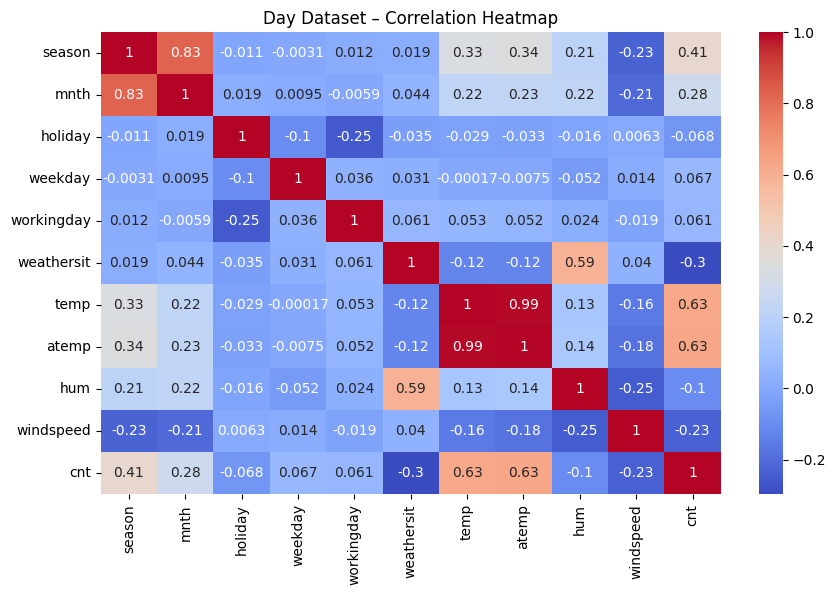

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(day.corr(), annot=True, cmap="coolwarm")
plt.title("Day Dataset – Correlation Heatmap")
plt.show()


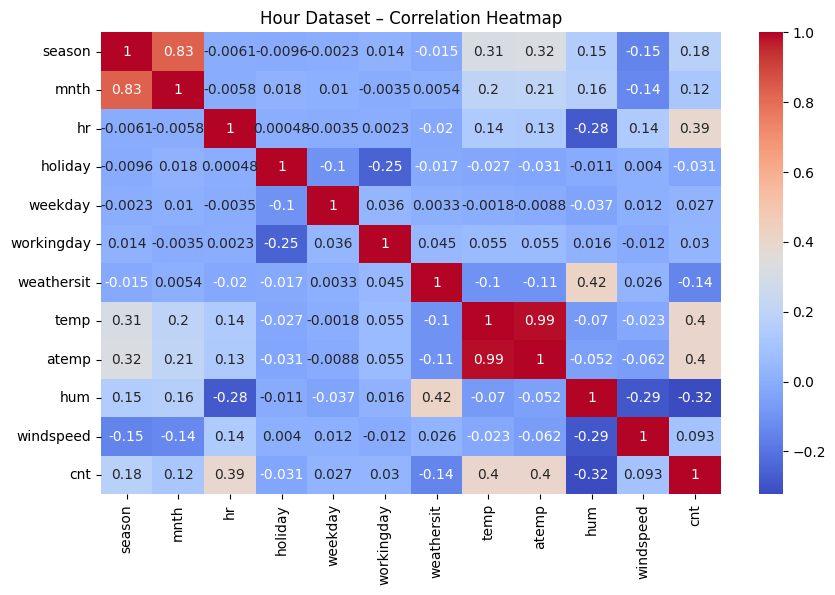

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(hour.corr(), annot=True, cmap="coolwarm")
plt.title("Hour Dataset – Correlation Heatmap")
plt.show()


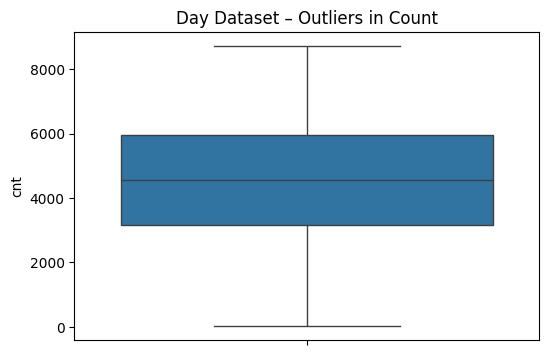

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(y=day['cnt'])
plt.title("Day Dataset – Outliers in Count")
plt.show()


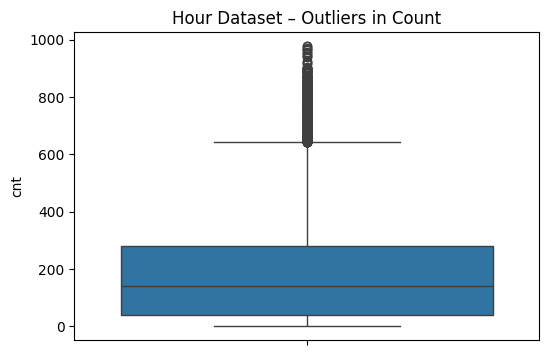

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(y=hour['cnt'])
plt.title("Hour Dataset – Outliers in Count")
plt.show()


In [23]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler


In [24]:
datasets = {
    "DAY": day,
    "HOUR": hour
}

splits = {}

for name, df in datasets.items():
    X = df.drop("cnt", axis=1)
    y = df["cnt"]

    splits[name] = train_test_split(
        X, y, test_size=0.2, random_state=42
    )


In [25]:
def evaluate(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    return {
        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),
        "MAE": mean_absolute_error(y_test, y_test_pred),
        "MSE": mean_squared_error(y_test, y_test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred))
    }


In [26]:
results_lr = {}

for name, (X_train, X_test, y_train, y_test) in splits.items():
    model = LinearRegression()
    model.fit(X_train, y_train)

    results_lr[name] = evaluate(model, X_train, y_train, X_test, y_test)

pd.DataFrame(results_lr).T


,Train R2,Test R2,MAE,MSE,RMSE
DAY,0.517645,0.551863,1143.393718,1.796978e+06,1340.514122
HOUR,0.337749,0.345547,106.754742,2.072353e+04,143.956690


In [27]:
param_dt = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

results_dt = {}

for name, (X_train, X_test, y_train, y_test) in splits.items():
    grid = GridSearchCV(
        DecisionTreeRegressor(random_state=42),
        param_dt,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    print(f"{name} Decision Tree Best Params:", grid.best_params_)

    results_dt[name] = evaluate(best_model, X_train, y_train, X_test, y_test)

pd.DataFrame(results_dt).T


DAY Decision Tree Best Params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
HOUR Decision Tree Best Params: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}


,Train R2,Test R2,MAE,MSE,RMSE
DAY,0.569273,0.469640,1235.728133,2.126680e+06,1458.313936
HOUR,0.849839,0.813552,50.720451,5.903942e+03,76.837112


In [28]:
param_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4]
}

results_gb = {}

for name, (X_train, X_test, y_train, y_test) in splits.items():
    grid = GridSearchCV(
        GradientBoostingRegressor(random_state=42),
        param_gb,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    print(f"{name} Gradient Boosting Best Params:", grid.best_params_)

    results_gb[name] = evaluate(best_model, X_train, y_train, X_test, y_test)

pd.DataFrame(results_gb).T


DAY Gradient Boosting Best Params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}
HOUR Gradient Boosting Best Params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}


,Train R2,Test R2,MAE,MSE,RMSE
DAY,0.719948,0.614162,1083.065662,1.547164e+06,1243.850628
HOUR,0.870698,0.855842,46.249315,4.564836e+03,67.563566


In [29]:
param_knn = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"]
}

results_knn = {}

for name, (X_train, X_test, y_train, y_test) in splits.items():
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    grid = GridSearchCV(
        KNeighborsRegressor(),
        param_knn,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    grid.fit(X_train_s, y_train)

    best_model = grid.best_estimator_
    print(f"{name} KNN Best Params:", grid.best_params_)

    results_knn[name] = evaluate(best_model, X_train_s, y_train, X_test_s, y_test)

pd.DataFrame(results_knn).T


DAY KNN Best Params: {'n_neighbors': 9, 'weights': 'distance'}
HOUR KNN Best Params: {'n_neighbors': 5, 'weights': 'distance'}


,Train R2,Test R2,MAE,MSE,RMSE
DAY,1.000000,0.583945,1128.313069,1.668330e+06,1291.638408
HOUR,0.999956,0.664436,68.014112,1.062579e+04,103.081449


In [30]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_svr(title, y_train, y_train_pred, y_test, y_test_pred):
    print("\n" + title)
    print("Train R2 :", r2_score(y_train, y_train_pred))
    print("Test  R2 :", r2_score(y_test, y_test_pred))
    print("MAE :", mean_absolute_error(y_test, y_test_pred))
    print("MSE :", mean_squared_error(y_test, y_test_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))


In [32]:
svr_grid.fit(X_train_day_s, y_train_day)

svr_day_best = svr_grid.best_estimator_
print("DAY SVR Best Params:", svr_grid.best_params_)

y_train_pred_day = svr_day_best.predict(X_train_day_s)
y_test_pred_day  = svr_day_best.predict(X_test_day_s)

evaluate_svr(
    "SVR – DAY DATASET",
    y_train_day, y_train_pred_day,
    y_test_day, y_test_pred_day
)


NameError: name 'svr_grid' is not defined

In [33]:
from sklearn.preprocessing import StandardScaler

scaler_hour = StandardScaler()
X_train_hour_s = scaler_hour.fit_transform(X_train_hour)
X_test_hour_s  = scaler_hour.transform(X_test_hour)


NameError: name 'X_train_hour' is not defined

In [43]:
svr_grid.fit(X_train_hour_s, y_train_hour)


,estimator,SVR()
,param_grid,"{'C': [1, 10], 'gamma': ['scale']}"
,scoring,'r2'
,n_jobs,1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'rbf'


In [44]:
svr_hour_best = svr_grid.best_estimator_
print("HOUR SVR Best Params:", svr_grid.best_params_)


HOUR SVR Best Params: {'C': 10, 'gamma': 'scale'}


In [45]:
y_train_pred_hour = svr_hour_best.predict(X_train_hour_s)
y_test_pred_hour  = svr_hour_best.predict(X_test_hour_s)


In [46]:
evaluate_svr(
    "SVR – HOUR DATASET",
    y_train_hour, y_train_pred_hour,
    y_test_hour, y_test_pred_hour
)



SVR – HOUR DATASET
Train R2 : 0.47155011133587965
Test  R2 : 0.47565142854604425
MAE : 82.15450799564123
MSE : 16603.713198772977
RMSE: 128.8553964674083


In [47]:
results_gb = {
    "DAY":  {"Train R2": ..., "Test R2": ..., "RMSE": ...},
    "HOUR": {"Train R2": ..., "Test R2": ..., "RMSE": ...}
}


In [48]:
import pandas as pd

final_day_models = pd.DataFrame({
    "Linear Regression": results_lr["DAY"],
    "Decision Tree": results_dt["DAY"],
    "Gradient Boosting": results_gb["DAY"],
    "SVR": results_svr["DAY"],
    "KNN": results_knn["DAY"]
}).T

final_day_models


,Train R2,Test R2,MAE,MSE,RMSE
Linear Regression,0.517645,0.551863,1143.393718,1796978.111447,1340.514122
Decision Tree,0.569273,0.46964,1235.728133,2126679.535055,1458.313936
Gradient Boosting,Ellipsis,Ellipsis,NaN,NaN,Ellipsis
SVR,0.391223,0.408911,1314.281368,2370198.23332,1539.544814
KNN,1.0,0.583945,1128.313069,1668329.77663,1291.638408


In [50]:
print(results_svr)


{'DAY': {'Train R2': 0.3912231508116124, 'Test R2': 0.4089107702567253, 'MAE': 1314.2813680200156, 'MSE': 2370198.2333199973, 'RMSE': np.float64(1539.5448136770808)}}


In [51]:
results_svr = {
    "DAY": {
        "Train R2": ...,
        "Test R2": ...,
        "MAE": ...,
        "MSE": ...,
        "RMSE": ...
    },
    "HOUR": {
        "Train R2": ...,
        "Test R2": ...,
        "MAE": ...,
        "MSE": ...,
        "RMSE": ...
    }
}


In [52]:
results_svr = {
    "DAY": {
        "Train R2": r2_score(y_train_day, y_train_pred_day),
        "Test R2": r2_score(y_test_day, y_test_pred_day),
        "MAE": mean_absolute_error(y_test_day, y_test_pred_day),
        "MSE": mean_squared_error(y_test_day, y_test_pred_day),
        "RMSE": np.sqrt(mean_squared_error(y_test_day, y_test_pred_day))
    },
    "HOUR": {
        "Train R2": r2_score(y_train_hour, y_train_pred_hour),
        "Test R2": r2_score(y_test_hour, y_test_pred_hour),
        "MAE": mean_absolute_error(y_test_hour, y_test_pred_hour),
        "MSE": mean_squared_error(y_test_hour, y_test_pred_hour),
        "RMSE": np.sqrt(mean_squared_error(y_test_hour, y_test_pred_hour))
    }
}


In [53]:
final_hour_models = pd.DataFrame({
    "Linear Regression": results_lr["HOUR"],
    "Decision Tree": results_dt["HOUR"],
    "Gradient Boosting": results_gb["HOUR"],
    "SVR": results_svr["HOUR"],
    "KNN": results_knn["HOUR"]
}).T


In [55]:
final_hour_models = final_hour_models.apply(pd.to_numeric, errors="coerce")


In [56]:
final_hour_models = final_hour_models.dropna()


In [57]:
final_hour_models.sort_values(
    by=["Test R2", "RMSE"],
    ascending=[False, True]
)


,Train R2,Test R2,MAE,MSE,RMSE
Decision Tree,0.849839,0.813552,50.720451,5903.941814,76.837112
KNN,0.999956,0.664436,68.014112,10625.785138,103.081449
SVR,0.471550,0.475651,82.154508,16603.713199,128.855396
Linear Regression,0.337749,0.345547,106.754742,20723.528553,143.956690


In [58]:
results_svr = {
    "DAY": {
        "Train R2": float(r2_score(y_train_day, y_train_pred_day)),
        "Test R2": float(r2_score(y_test_day, y_test_pred_day)),
        "MAE": float(mean_absolute_error(y_test_day, y_test_pred_day)),
        "MSE": float(mean_squared_error(y_test_day, y_test_pred_day)),
        "RMSE": float(np.sqrt(mean_squared_error(y_test_day, y_test_pred_day)))
    },
    "HOUR": {
        "Train R2": float(r2_score(y_train_hour, y_train_pred_hour)),
        "Test R2": float(r2_score(y_test_hour, y_test_pred_hour)),
        "MAE": float(mean_absolute_error(y_test_hour, y_test_pred_hour)),
        "MSE": float(mean_squared_error(y_test_hour, y_test_pred_hour)),
        "RMSE": float(np.sqrt(mean_squared_error(y_test_hour, y_test_pred_hour)))
    }
}
